# 03 - Résultats du Traitement des Données Texte

## Section : Gestion du Texte

### Objectif
Valider les résultats du preprocessing effectué dans le notebook 02 : statistiques avant/après, visualisations, contrôles de qualité.

**Prérequis** : Exécuter d'abord `02_texte_traitement_donnees.ipynb` pour générer les fichiers dans `data/processed/`.




In [21]:
# Chargement des données (nécessite d'avoir exécuté 02_texte_traitement_donnees)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append(str(Path('../').resolve()))

from src.preprocessing import has_html
from src.utils.data_loader import load_data

DATA_DIR = Path('../data brut')
OUTPUT_DIR = Path('../data/processed')

# Données brutes (pour comparaison avant)
X_train_original, y_train, X_test_original = load_data(data_dir=DATA_DIR)

# Données traitées (sortie du notebook 02)
X_train_final = pd.read_csv(OUTPUT_DIR / 'X_train_clean.csv')
X_test_final = pd.read_csv(OUTPUT_DIR / 'X_test_clean.csv')

print("✅ Données chargées pour validation")



🔄 Chargement des données...
✅ Données chargées avec succès !
  - X_train : 84,916 lignes × 5 colonnes
  - y_train : 84,916 lignes × 2 colonnes
  - X_test  : 13,812 lignes × 5 colonnes
✅ Données chargées pour validation


## 1. Statistiques et Validation

### 1.1 Comparaison avant/après preprocessing


In [22]:
# Données chargées dans la cellule précédente

print("="*80)
print("COMPARAISON AVANT / APRÈS PREPROCESSING")
print("="*80)

# Statistiques avant
print("\n📊 AVANT PREPROCESSING :")
print(f"  - Descriptions avec HTML : {X_train_original['description'].apply(has_html).sum()} ({X_train_original['description'].apply(has_html).sum()/len(X_train_original)*100:.2f}%)")
print(f"  - Descriptions manquantes : {X_train_original['description'].isna().sum()} ({X_train_original['description'].isna().sum()/len(X_train_original)*100:.2f}%)")
print(f"  - Longueur moyenne description : {X_train_original['description'].fillna('').astype(str).str.len().mean():.1f} caractères")

# Statistiques après
# Vérifier le HTML sur les descriptions nettoyées (pas sur has_html qui est calculé avant nettoyage)
html_after_clean = X_train_final['description_clean'].apply(has_html).sum()
print("\n📊 APRÈS PREPROCESSING :")
print(f"  - Descriptions avec HTML restant : {html_after_clean} ({html_after_clean/len(X_train_final)*100:.2f}%)")
print(f"  - Descriptions vides : {(X_train_final['description_clean'] == '').sum()} ({(X_train_final['description_clean'] == '').sum()/len(X_train_final)*100:.2f}%)")
print(f"  - Longueur moyenne text_combined : {X_train_final['text_combined'].str.len().mean():.1f} caractères")
print(f"  - Features créées : {len([c for c in X_train_final.columns if c not in ['productid', 'imageid', 'designation_clean', 'description_clean', 'text_combined']])}")



COMPARAISON AVANT / APRÈS PREPROCESSING

📊 AVANT PREPROCESSING :
  - Descriptions avec HTML : 15645 (18.42%)
  - Descriptions manquantes : 29800 (35.09%)
  - Longueur moyenne description : 524.6 caractères

📊 APRÈS PREPROCESSING :
  - Descriptions avec HTML restant : 0 (0.00%)
  - Descriptions vides : 0 (0.00%)
  - Longueur moyenne text_combined : 559.2 caractères
  - Features créées : 12


### 1.2 Visualisations de validation


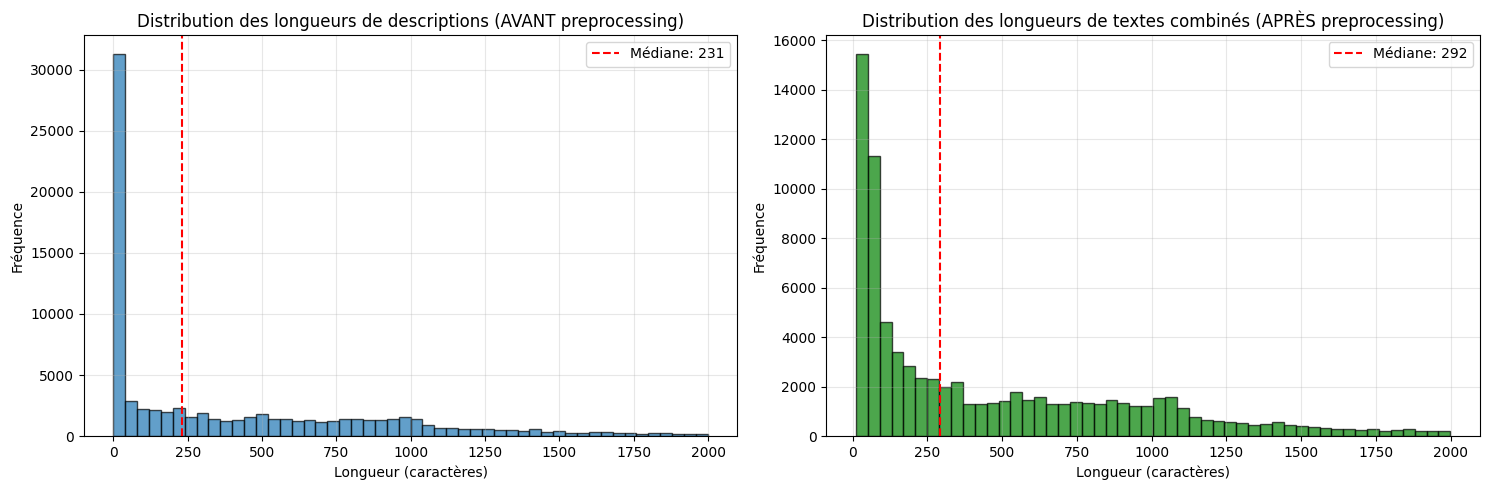

In [23]:
# Visualisation 1 : Distribution des longueurs avant/après
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Avant
desc_lengths_before = X_train_original['description'].fillna('').astype(str).str.len()
axes[0].hist(desc_lengths_before[desc_lengths_before < 2000], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des longueurs de descriptions (AVANT preprocessing)')
axes[0].axvline(desc_lengths_before.median(), color='r', linestyle='--', label=f'Médiane: {desc_lengths_before.median():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Après
desc_lengths_after = X_train_final['text_combined'].str.len()
axes[1].hist(desc_lengths_after[desc_lengths_after < 2000], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Longueur (caractères)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des longueurs de textes combinés (APRÈS preprocessing)')
axes[1].axvline(desc_lengths_after.median(), color='r', linestyle='--', label=f'Médiane: {desc_lengths_after.median():.0f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



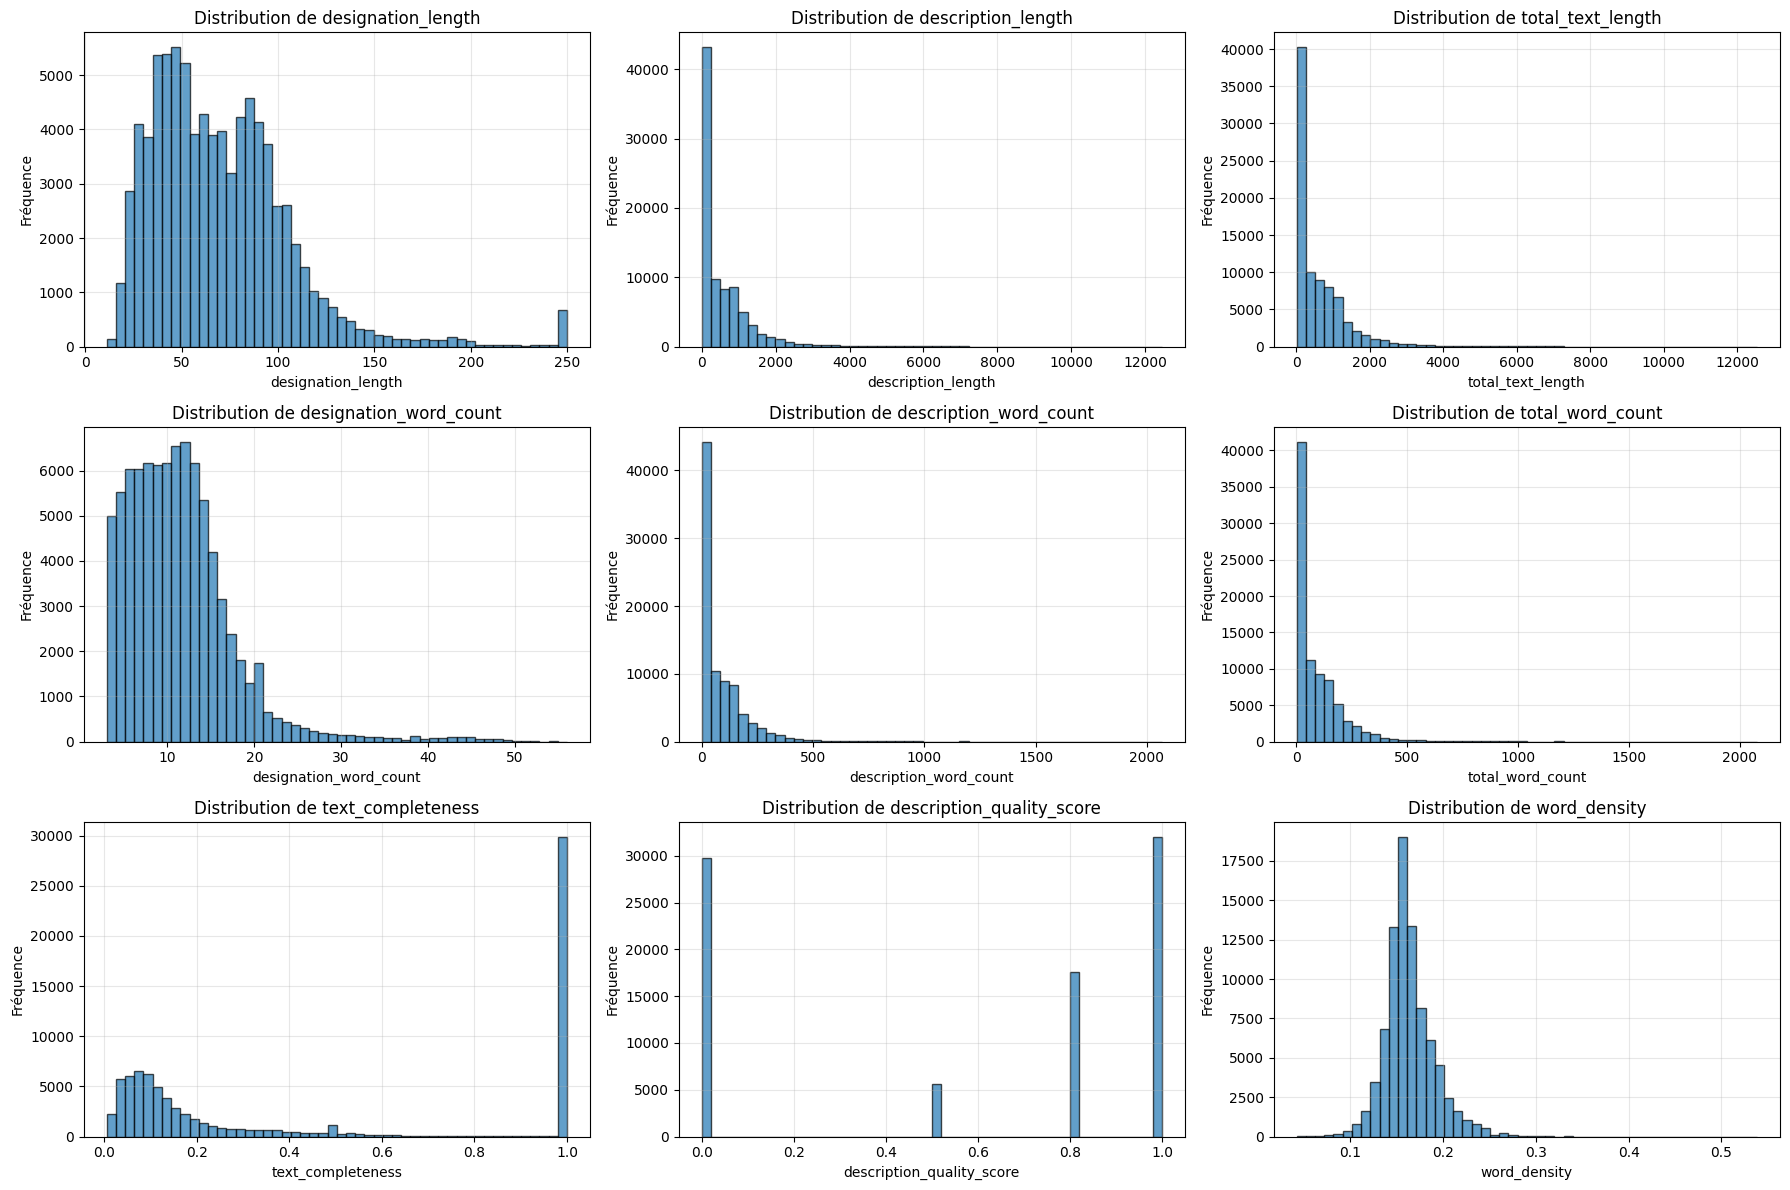

In [24]:
# Visualisation 2 : Features créées
feature_cols_numeric = [
    'designation_length', 'description_length', 'total_text_length',
    'designation_word_count', 'description_word_count', 'total_word_count',
    'text_completeness', 'description_quality_score', 'word_density'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(feature_cols_numeric):
    if col in X_train_final.columns:
        axes[idx].hist(X_train_final[col], bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Fréquence')
        axes[idx].set_title(f'Distribution de {col}')
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()



### 7.3 Validation finale

Vérification de la cohérence des données et absence d'erreurs.


In [25]:
# Validation finale
print("="*80)
print("VALIDATION FINALE")
print("="*80)

# Vérifications
checks = []

# 1. Pas de NaN dans les colonnes importantes
checks.append(('Pas de NaN dans text_combined', X_train_final['text_combined'].isna().sum() == 0))
checks.append(('Pas de NaN dans designation_clean', X_train_final['designation_clean'].isna().sum() == 0))

# 2. Pas de textes vides
checks.append(('Pas de textes vides', (X_train_final['text_combined'] == '').sum() == 0))

# 3. Cohérence train/test
checks.append(('Même nombre de colonnes train/test', X_train_final.shape[1] == X_test_final.shape[1]))
checks.append(('Colonnes identiques train/test', list(X_train_final.columns) == list(X_test_final.columns)))

# 4. Pas de HTML restant (vérifier sur les descriptions nettoyées)
html_remaining_clean = X_train_final['description_clean'].apply(has_html).sum()
checks.append(('Pas de HTML restant dans description_clean', html_remaining_clean == 0))

# Afficher les résultats
print("\n✅ Résultats des vérifications :")
for check_name, check_result in checks:
    status = "✅" if check_result else "❌"
    print(f"  {status} {check_name}")

all_passed = all(result for _, result in checks)
if all_passed:
    print("\n🎉 Toutes les validations sont passées ! Le dataset est prêt pour la modélisation.")
else:
    print("\n⚠️  Certaines validations ont échoué. Vérifiez les données.")



VALIDATION FINALE

✅ Résultats des vérifications :
  ✅ Pas de NaN dans text_combined
  ✅ Pas de NaN dans designation_clean
  ✅ Pas de textes vides
  ✅ Même nombre de colonnes train/test
  ✅ Colonnes identiques train/test
  ✅ Pas de HTML restant dans description_clean

🎉 Toutes les validations sont passées ! Le dataset est prêt pour la modélisation.


## 2. Synthèse et Prochaines Étapes

### Résumé du Preprocessing

Le preprocessing a été effectué avec succès :
- ✅ HTML nettoyé des descriptions
- ✅ Valeurs manquantes gérées
- ✅ Textes normalisés
- ✅ Features supplémentaires créées
- ✅ Datasets prêts pour la modélisation

### Prochaines étapes

1. **Modélisation** : Utiliser les datasets nettoyés pour entraîner des modèles
2. **Vectorisation** : Transformer les textes en vecteurs (TF-IDF, Word2Vec, BERT, etc.)
3. **Sélection de modèle** : Tester différents algorithmes (Naive Bayes, SVM, Random Forest, etc.)
4. **Évaluation** : Mesurer les performances avec des métriques adaptées au déséquilibre

### Fichiers générés

- `data/processed/X_train_clean.csv` : Dataset d'entraînement nettoyé
- `data/processed/X_test_clean.csv` : Dataset de test nettoyé
- `data/processed/y_train.csv` : Labels d'entraînement

